In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
from bs4 import BeautifulSoup
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("train.csv")
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [3]:
new_df = df.sample(60000, random_state=42)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate
8067,8067,15738,15739,How do I play Pokémon GO in Korea?,How do I play Pokémon GO in China?,0
368101,368101,12736,104117,What are some of the best side dishes for crab...,What are some good side dishes for buffalo chi...,0
70497,70497,121486,121487,Which is more advisable and better material fo...,What is the best server setup for buddypress?,0
226567,226567,254474,258192,How do I improve logical programming skills?,How can I improve my logical skills for progra...,1
73186,73186,48103,3062,How close we are to see 3rd world war?,How close is a World War III?,1


In [4]:
def preprocess_text(q):
    q=str(q).lower().strip()
    #replace certain special characters with their string equivalent
    q = q.replace("%", " percent")
    q = q.replace("$", " dollar ")
    q = q.replace("₹", " rupee ")
    q = q.replace("€", " euro ")    
    q = q.replace("@", " at ")
#THE patter '[math] appears around 900 times in whole dataset. It is used to represent mathematical expressions. We will replace it with a space.
    q = q.replace("[math]", " ")
    #replace some numbers with string equivalent
    q = q.replace(',000,000,000','b')
    q = q.replace(',000,000','m')
    q = q.replace(',000','k')
    q = re.sub(r'([0-9]+)000000000', r'\1b', q)
    q = re.sub(r'([0-9]+)000000', r'\1m', q)
    q = re.sub(r'([0-9]+)000', r'\1k', q)
    #decontracting words

    contractions = { 
    "ain't": "am not / are not / is not / has not / have not",
    "aren't": "are not / am not",
    "can't": "cannot",
    "can't've": "cannot have",
    "'cause": "because",
    "could've": "could have",
    "couldn't": "could not",
    "couldn't've": "could not have",
"didn't": "did not",
"doesn't": "does not",
"don't": "do not",
"hadn't": "had not",
"hadn't've": "had not have",
"hasn't": "has not",
"haven't": "have not",
"he'd": "he had / he would",
"he'd've": "he would have",
"he'll": "he shall / he will",
"he'll've": "he shall have / he will have",
"he's": "he has / he is",
"how'd": "how did",
"how'd'y": "how do you",
"how'll": "how will",
"how's": "how has / how is / how does",
"I'd": "I had / I would",
"I'd've": "I would have",
"I'll": "I shall / I will",
"I'll've": "I shall have / I will have",
"I'm": "I am",
"I've": "I have",
"isn't": "is not",
"it'd": "it had / it would",
"it'd've": "it would have",
"it'll": "it shall / it will",
"it'll've": "it shall have / it will have",
"it's": "it has / it is",
"let's": "let us",
"ma'am": "madam",
"mayn't": "may not",
"might've": "might have",
"mightn't": "might not",
"mightn't've": "might not have",
"must've": "must have",
"mustn't": "must not",
"mustn't've": "must not have",
"needn't": "need not",
"needn't've": "need not have",
"o'clock": "of the clock",
"oughtn't": "ought not",
"oughtn't've": "ought not have",
"shan't": "shall not",
"sha'n't": "shall not",
"shan't've": "shall not have",
"she'd": "she had / she would",
"she'd've": "she would have",
"she'll": "she shall / she will",
"she'll've": "she shall have / she will have",
"she's": "she has / she is",
"should've": "should have",
"shouldn't": "should not",
"shouldn't've": "should not have",
"so've": "so have",
"so's": "so as / so is",
"that'd": "that would / that had",
"that'd've": "that would have",
"that's": "that has / that is",
"there'd": "there had / there would",
"there'd've": "there would have",
"there's": "there has / there is",
"they'd": "they had / they would",
"they'd've": "they would have",
"they'll": "they shall / they will",
"they'll've": "they shall have / they will have",
"they're": "they are",
"they've": "they have",
"to've": "to have",
"wasn't": "was not",
"we'd": "we had / we would",
"we'd've": "we would have",
"we'll": "we will",
"we'll've": "we will have",
"we're": "we are",
"we've": "we have",
"weren't": "were not",
"what'll": "what shall / what will",
"what'll've": "what shall have / what will have",
"what're": "what are",
"what's": "what has / what is",
"what've": "what have",
"when's": "when has / when is",
"when've": "when have",
"where'd": "where did",
"where's": "where has / where is",
"where've": "where have",
"who'll": "who shall / who will",
"who'll've": "who shall have / who will have",
"who's": "who has / who is",
"who've": "who have",
"why's": "why has / why is",
"why've": "why have",
"will've": "will have",
"won't": "will not",
"won't've": "will not have",
"would've": "would have",
"wouldn't": "would not",
"wouldn't've": "would not have",
"y'all": "you all",
"y'all'd": "you all would",
"y'all'd've": "you all would have",
"y'all're": "you all are",
"y'all've": "you all have",
"you'd": "you had / you would",
"you'd've": "you would have",
"you'll": "you shall / you will",
"you'll've": "you shall have / you will have",
"you're": "you are",
"you've": "you have"
}
    q_decontracted = []
    for word in q.split():
        if word in contractions:
            word = contractions[word]
        q_decontracted.append(word)
    q = ' '.join(q_decontracted)
    q = q.replace("'ve", " have")
    q = q.replace("n't", " not")
    q = q.replace("'re", " are")
    q = q.replace("'ll", " will")

    #remove html tags
    q = BeautifulSoup(q)
    q = q.get_text()

    #remove punctuations
    pattern = re.compile(r'[^\w\s]')
    q = re.sub(pattern, '', q).strip()
    return q



In [5]:
preprocess_text("I've already! wasn't <b>done<b>?")


'i have already was not done'

In [6]:
new_df['question1'] = new_df['question1'].apply(preprocess_text)
new_df['question2'] = new_df['question2'].apply(preprocess_text)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate
8067,8067,15738,15739,how do i play pokémon go in korea,how do i play pokémon go in china,0
368101,368101,12736,104117,what are some of the best side dishes for crab...,what are some good side dishes for buffalo chi...,0
70497,70497,121486,121487,which is more advisable and better material fo...,what is the best server setup for buddypress,0
226567,226567,254474,258192,how do i improve logical programming skills,how can i improve my logical skills for progra...,1
73186,73186,48103,3062,how close we are to see 3rd world war,how close is a world war iii,1


In [7]:
new_df['q1_len'] = new_df['question1'].str.len() 
new_df['q2_len'] = new_df['question2'].str.len()
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len
8067,8067,15738,15739,how do i play pokémon go in korea,how do i play pokémon go in china,0,33,33
368101,368101,12736,104117,what are some of the best side dishes for crab...,what are some good side dishes for buffalo chi...,0,52,50
70497,70497,121486,121487,which is more advisable and better material fo...,what is the best server setup for buddypress,0,94,44
226567,226567,254474,258192,how do i improve logical programming skills,how can i improve my logical skills for progra...,1,43,51
73186,73186,48103,3062,how close we are to see 3rd world war,how close is a world war iii,1,37,28


In [8]:
new_df['q1_num_words'] = new_df['question1'].apply(lambda x: len(x.split(" ")))
new_df['q2_num_words'] = new_df['question2'].apply(lambda x: len(x.split(" ")))
new_df

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words
8067,8067,15738,15739,how do i play pokémon go in korea,how do i play pokémon go in china,0,33,33,8,8
368101,368101,12736,104117,what are some of the best side dishes for crab...,what are some good side dishes for buffalo chi...,0,52,50,11,9
70497,70497,121486,121487,which is more advisable and better material fo...,what is the best server setup for buddypress,0,94,44,16,8
226567,226567,254474,258192,how do i improve logical programming skills,how can i improve my logical skills for progra...,1,43,51,7,9
73186,73186,48103,3062,how close we are to see 3rd world war,how close is a world war iii,1,37,28,9,7
...,...,...,...,...,...,...,...,...,...,...
286873,286873,407541,287156,what does it mean when he writes you an email ...,how often should i text my crush every day two...,0,82,63,17,14
199146,199146,106586,4860,is it possible to lose 40 pounds in one month,is it safe to lose 40 pounds in 2 weeks,1,45,39,10,10
42216,42216,18801,76111,is it possible that jaime lannister could be a...,is it possible that jaime lannister is azor ah...,1,54,133,10,24
288229,288229,180779,409156,can i hack google,can anyone literally hack google,1,17,32,4,5


In [9]:
def common_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return len(w1 & w2)

In [10]:
new_df["words_common"] = new_df.apply(common_words, axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,words_common
8067,8067,15738,15739,how do i play pokémon go in korea,how do i play pokémon go in china,0,33,33,8,8,7
368101,368101,12736,104117,what are some of the best side dishes for crab...,what are some good side dishes for buffalo chi...,0,52,50,11,9,6
70497,70497,121486,121487,which is more advisable and better material fo...,what is the best server setup for buddypress,0,94,44,16,8,2
226567,226567,254474,258192,how do i improve logical programming skills,how can i improve my logical skills for progra...,1,43,51,7,9,6
73186,73186,48103,3062,how close we are to see 3rd world war,how close is a world war iii,1,37,28,9,7,4


In [ ]:
def total_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return (len(w1) + len(w2))

In [12]:
new_df["total_words"] = new_df.apply(total_words, axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,words_common,total_words
8067,8067,15738,15739,how do i play pokémon go in korea,how do i play pokémon go in china,0,33,33,8,8,7,16
368101,368101,12736,104117,what are some of the best side dishes for crab...,what are some good side dishes for buffalo chi...,0,52,50,11,9,6,20
70497,70497,121486,121487,which is more advisable and better material fo...,what is the best server setup for buddypress,0,94,44,16,8,2,24
226567,226567,254474,258192,how do i improve logical programming skills,how can i improve my logical skills for progra...,1,43,51,7,9,6,16
73186,73186,48103,3062,how close we are to see 3rd world war,how close is a world war iii,1,37,28,9,7,4,16


In [13]:
new_df['word_share'] = new_df['words_common'] / new_df['total_words']
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,words_common,total_words,word_share
8067,8067,15738,15739,how do i play pokémon go in korea,how do i play pokémon go in china,0,33,33,8,8,7,16,0.437500
368101,368101,12736,104117,what are some of the best side dishes for crab...,what are some good side dishes for buffalo chi...,0,52,50,11,9,6,20,0.300000
70497,70497,121486,121487,which is more advisable and better material fo...,what is the best server setup for buddypress,0,94,44,16,8,2,24,0.083333
226567,226567,254474,258192,how do i improve logical programming skills,how can i improve my logical skills for progra...,1,43,51,7,9,6,16,0.375000
73186,73186,48103,3062,how close we are to see 3rd world war,how close is a world war iii,1,37,28,9,7,4,16,0.250000


In [14]:
#advanced features
from nltk.corpus import stopwords
def fetch_token_features(row):
    q1 = row['question1']
    q2 = row['question2']
    SAFE_DIV = 0.0001 #to prevent division by zero
    STOP_WORDS = (stopwords.words("english"))
    token_features=[0.0]*8

    #Converting sentences into tokens:
    q1_tokens = q1.split()
    q2_tokens = q2.split()
    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return token_features
    
    # GET the non stop words in the questions:
    q1_words = set([word for word in q1_tokens if word not in STOP_WORDS])
    q2_words = set([word for word in q2_tokens if word not in STOP_WORDS])

    #GET the stop words in the questions:
    q1_stops = set([word for word in q1_tokens if word in STOP_WORDS])
    q2_stops = set([word for word in q2_tokens if word in STOP_WORDS])

    #Get the common non stop words in the questions:
    common_word_count = len(q1_words &q2_words)

    #get the common stop words in the questions:
    common_stop_count = len(q1_stops &q2_stops)
    
    #Get the common tokens in the questions:
    common_token_count = len(set(q1_tokens) & set(q2_tokens))




    token_features[0] = common_word_count / (min(len(q1_words), len(q2_words)) + SAFE_DIV) #common non stop words divided by the min number of non stop words in a question
    token_features[1] = common_word_count / (max(len(q1_words), len(q2_words)) + SAFE_DIV) #common non stop words divided by the max number of non stop words in a question
    token_features[2] = common_stop_count / (min(len(q1_stops), len(q2_stops)) + SAFE_DIV) #common stop words divided by the min number of stop words in a question
    token_features[3] = common_stop_count / (max(len(q1_stops), len(q2_stops)) + SAFE_DIV) #common stop words divided by the max number of stop words in a question
    token_features[4] = common_token_count / (min(len(q1_tokens), len(q2_tokens)) + SAFE_DIV) #common tokens divided by the min number of tokens in a question
    token_features[5] = common_token_count / (max(len(q1_tokens), len(q2_tokens)) + SAFE_DIV) #common tokens divided by the max number of tokens in a question

    #Last word of both is similar or not
    token_features[6] = int(q1_tokens[-1] == q2_tokens[-1])

    #First word of both is similar or not
    token_features[7] = int(q1_tokens[0] == q2_tokens[0])
    
    return token_features

In [15]:
token_features  = new_df.apply(fetch_token_features, axis=1)
new_df["cwc_min"] = list(map(lambda x: x[0], token_features))
new_df["cwc_max"] = list(map(lambda x: x[1], token_features))
new_df["csc_min"] = list(map(lambda x: x[2], token_features))
new_df["csc_max"] = list(map(lambda x: x[3], token_features))
new_df["ctc_min"] = list(map(lambda x: x[4], token_features))
new_df["ctc_max"] = list(map(lambda x: x[5], token_features))
new_df["last_word_eq"] = list(map(lambda x: x[6], token_features))
new_df["first_word_eq"] = list(map(lambda x: x[7], token_features))
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,total_words,word_share,cwc_min,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq
8067,8067,15738,15739,how do i play pokémon go in korea,how do i play pokémon go in china,0,33,33,8,8,...,16,0.437500,0.749981,0.749981,0.999975,0.999975,0.874989,0.874989,0.0,1.0
368101,368101,12736,104117,what are some of the best side dishes for crab...,what are some good side dishes for buffalo chi...,0,52,50,11,9,...,20,0.300000,0.399992,0.399992,0.999975,0.666656,0.666659,0.545450,0.0,1.0
70497,70497,121486,121487,which is more advisable and better material fo...,what is the best server setup for buddypress,0,94,44,16,8,...,24,0.083333,0.000000,0.000000,0.499988,0.249997,0.249997,0.124999,0.0,0.0
226567,226567,254474,258192,how do i improve logical programming skills,how can i improve my logical skills for progra...,1,43,51,7,9,...,16,0.375000,0.999975,0.999975,0.666644,0.399992,0.857131,0.666659,0.0,1.0
73186,73186,48103,3062,how close we are to see 3rd world war,how close is a world war iii,1,37,28,9,7,...,16,0.250000,0.749981,0.599988,0.333322,0.249994,0.571420,0.444440,0.0,1.0


In [16]:
import distance
def fetch_length_features(row):
    q1 = row['question1']
    q2 = row['question2']
    length_features = [0.0]*3
    # Converting the sentence into tokens:
    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return length_features
    
    #Absolute length features

    length_features[0] = abs(len(q1) - len(q2)) #absolute length difference between the questions

    #Aveage token length of both questions

    length_features[1] = (len(q1_tokens) + len(q2_tokens)) / 2 #average token length of both questions

    strs = list(distance.lcsubstrings(q1,q2))
    length_features[2] = len(strs[0]) / (min(len(q1), len(q2)) + 1) if strs else 0 #length of longest common substring divided by the min length of the questions

    return length_features


In [17]:
length_features = new_df.apply(fetch_length_features, axis=1)
new_df["abs_len_diff"] = list(map(lambda x: x[0], length_features))
new_df["mean_len"] = list(map(lambda x: x[1], length_features))
new_df["longest_substr_ratio"] = list(map(lambda x: x[2], length_features))
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio
8067,8067,15738,15739,how do i play pokémon go in korea,how do i play pokémon go in china,0,33,33,8,8,...,0.749981,0.999975,0.999975,0.874989,0.874989,0.0,1.0,0.0,8.0,0.823529
368101,368101,12736,104117,what are some of the best side dishes for crab...,what are some good side dishes for buffalo chi...,0,52,50,11,9,...,0.399992,0.999975,0.666656,0.666659,0.545450,0.0,1.0,2.0,10.0,0.333333
70497,70497,121486,121487,which is more advisable and better material fo...,what is the best server setup for buddypress,0,94,44,16,8,...,0.000000,0.499988,0.249997,0.249997,0.124999,0.0,0.0,50.0,12.0,0.111111
226567,226567,254474,258192,how do i improve logical programming skills,how can i improve my logical skills for progra...,1,43,51,7,9,...,0.999975,0.666644,0.399992,0.857131,0.666659,0.0,1.0,8.0,8.0,0.272727
73186,73186,48103,3062,how close we are to see 3rd world war,how close is a world war iii,1,37,28,9,7,...,0.599988,0.333322,0.249994,0.571420,0.444440,0.0,1.0,9.0,8.0,0.344828


In [18]:
#fuzzy features
from fuzzywuzzy import fuzz

def fetch_fuzzy_features(row):
    q1 = row['question1']
    q2 = row['question2']
    fuzzy_features = [0.0]*4
    fuzzy_features[0] = fuzz.QRatio(q1, q2) / 100 #QRatio is a simple Levenshtein distance similarity measure.
    fuzzy_features[1] = fuzz.partial_ratio(q1, q2) / 100 #Partial ratio is a measure of the similarity of the shorter string to substrings of the longer string.
    fuzzy_features[2] = fuzz.token_sort_ratio(q1, q2) / 100 #Token sort ratio is a measure of similarity that ignores word order.
    fuzzy_features[3] = fuzz.token_set_ratio(q1, q2) / 100 #Token set ratio is a measure of similarity that ignores duplicate words and word order.
    return fuzzy_features



In [19]:
fuzzy_features = new_df.apply(fetch_fuzzy_features, axis=1)
new_df["fuzz_qratio"] = list(map(lambda x: x[0], fuzzy_features))
new_df["fuzz_partial_ratio"] = list(map(lambda x: x[1], fuzzy_features))
new_df['token_sort_ratio'] = list(map(lambda x: x[2], fuzzy_features))
new_df['token_set_ratio'] = list(map(lambda x: x[3], fuzzy_features))
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_qratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
8067,8067,15738,15739,how do i play pokémon go in korea,how do i play pokémon go in china,0,33,33,8,8,...,0.874989,0.0,1.0,0.0,8.0,0.823529,0.88,0.88,0.81,0.90
368101,368101,12736,104117,what are some of the best side dishes for crab...,what are some good side dishes for buffalo chi...,0,52,50,11,9,...,0.545450,0.0,1.0,2.0,10.0,0.333333,0.73,0.72,0.73,0.73
70497,70497,121486,121487,which is more advisable and better material fo...,what is the best server setup for buddypress,0,94,44,16,8,...,0.124999,0.0,0.0,50.0,12.0,0.111111,0.35,0.43,0.36,0.24
226567,226567,254474,258192,how do i improve logical programming skills,how can i improve my logical skills for progra...,1,43,51,7,9,...,0.666659,0.0,1.0,8.0,8.0,0.272727,0.72,0.67,0.89,0.96
73186,73186,48103,3062,how close we are to see 3rd world war,how close is a world war iii,1,37,28,9,7,...,0.444440,0.0,1.0,9.0,8.0,0.344828,0.68,0.61,0.71,0.81


In [20]:
print(new_df.shape)
new_df.head()

(60000, 28)


,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_qratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
8067,8067,15738,15739,how do i play pokémon go in korea,how do i play pokémon go in china,0,33,33,8,8,...,0.874989,0.0,1.0,0.0,8.0,0.823529,0.88,0.88,0.81,0.90
368101,368101,12736,104117,what are some of the best side dishes for crab...,what are some good side dishes for buffalo chi...,0,52,50,11,9,...,0.545450,0.0,1.0,2.0,10.0,0.333333,0.73,0.72,0.73,0.73
70497,70497,121486,121487,which is more advisable and better material fo...,what is the best server setup for buddypress,0,94,44,16,8,...,0.124999,0.0,0.0,50.0,12.0,0.111111,0.35,0.43,0.36,0.24
226567,226567,254474,258192,how do i improve logical programming skills,how can i improve my logical skills for progra...,1,43,51,7,9,...,0.666659,0.0,1.0,8.0,8.0,0.272727,0.72,0.67,0.89,0.96
73186,73186,48103,3062,how close we are to see 3rd world war,how close is a world war iii,1,37,28,9,7,...,0.444440,0.0,1.0,9.0,8.0,0.344828,0.68,0.61,0.71,0.81


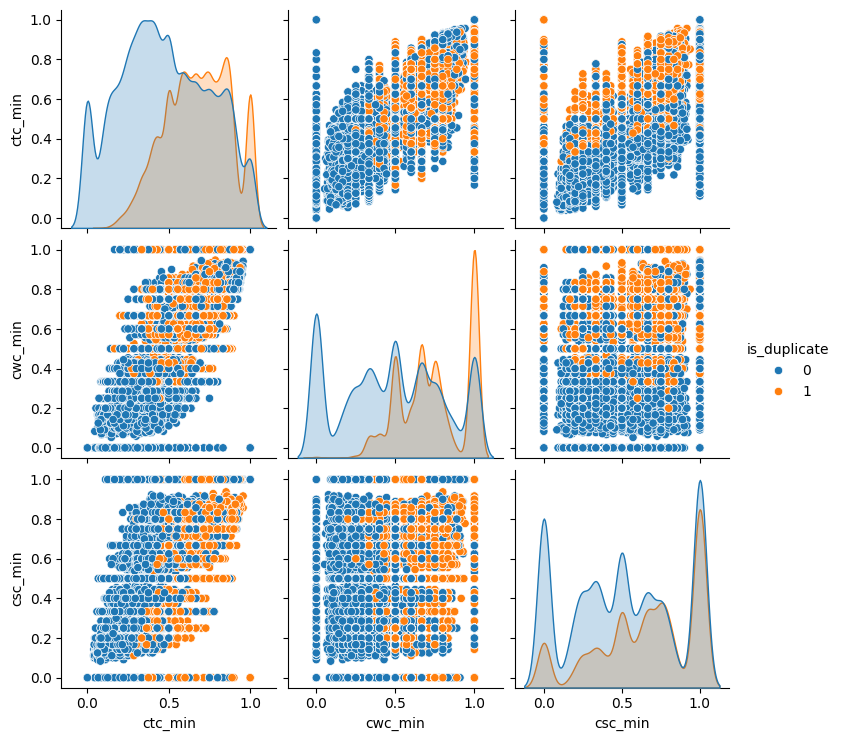

In [21]:
sns.pairplot(new_df[["ctc_min",'cwc_min','csc_min','is_duplicate']],hue="is_duplicate")

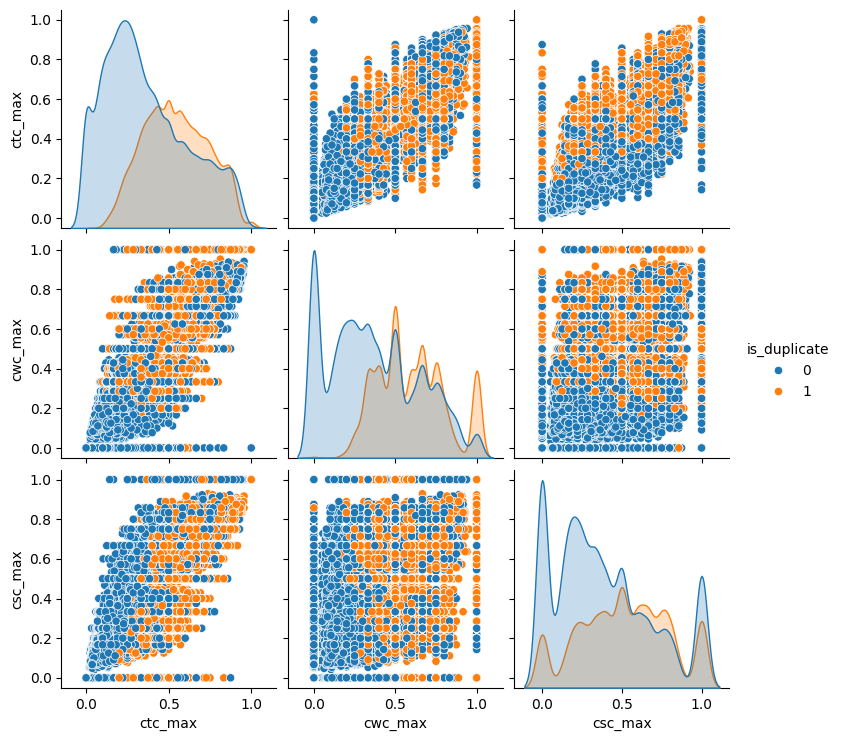

In [22]:
sns.pairplot(new_df[["ctc_max",'cwc_max','csc_max','is_duplicate']],hue="is_duplicate")

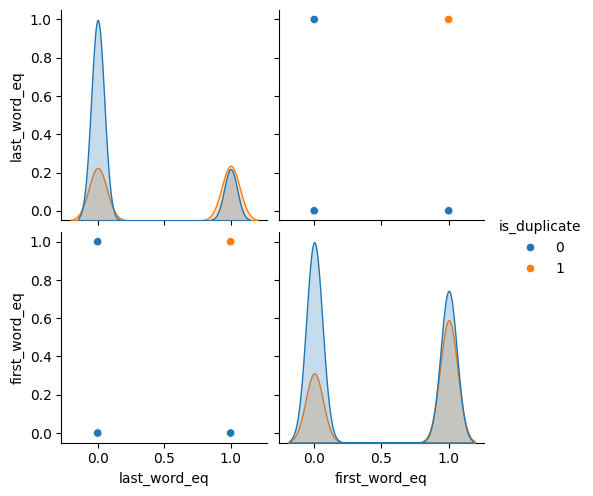

In [23]:
sns.pairplot(new_df[['last_word_eq','first_word_eq','is_duplicate']],hue="is_duplicate")

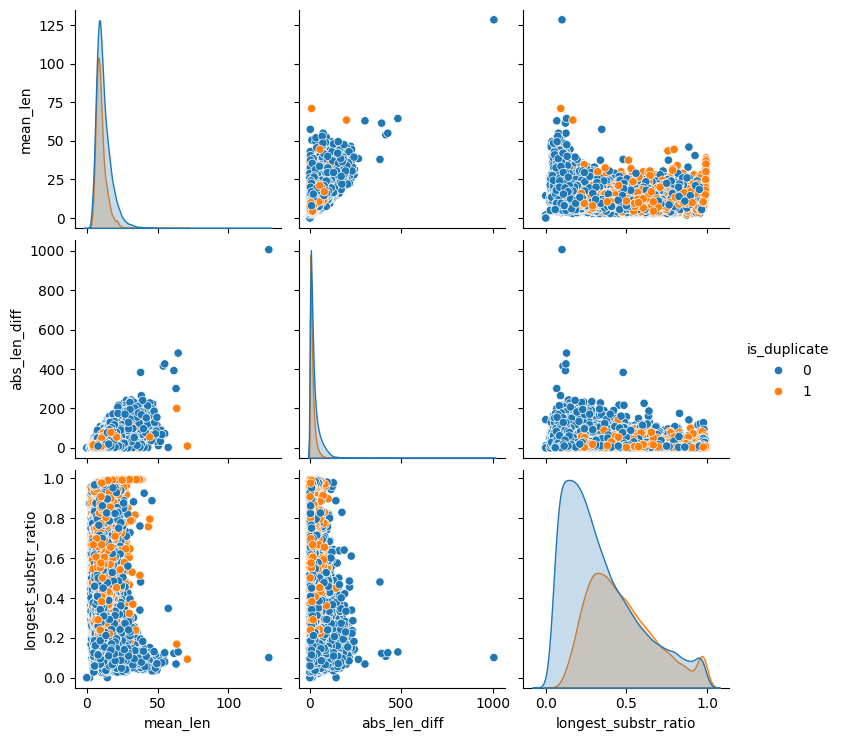

In [24]:
sns.pairplot(new_df[['mean_len','abs_len_diff','longest_substr_ratio','is_duplicate']],hue="is_duplicate")


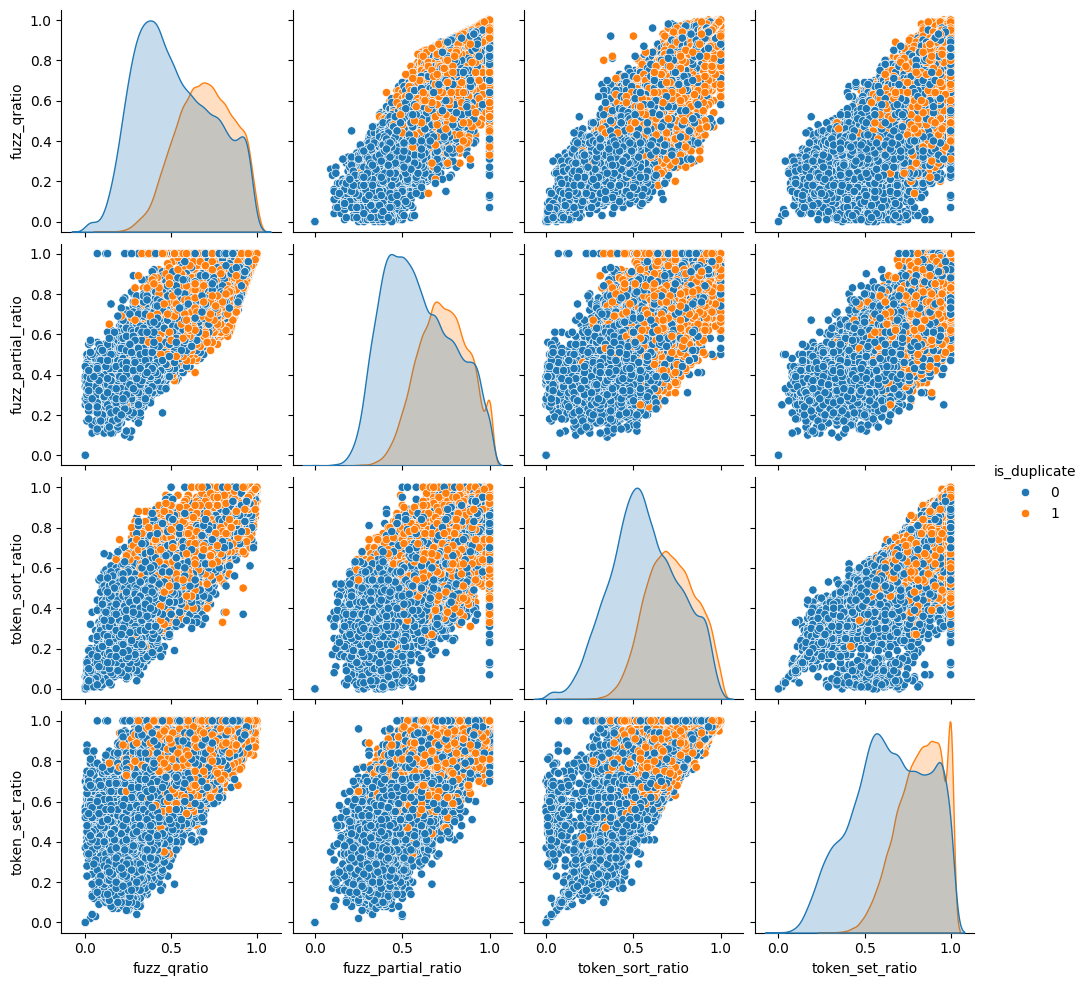

In [25]:
sns.pairplot(new_df[['fuzz_qratio','fuzz_partial_ratio','token_sort_ratio','token_set_ratio','is_duplicate']],hue="is_duplicate")

In [26]:
#using TSNE for dimensionality reduction for 15 features to 3 features and visualizing the same

from sklearn.preprocessing import MinMaxScaler

x = MinMaxScaler().fit_transform(new_df[["cwc_min","cwc_max","csc_min","csc_max","ctc_min","ctc_max","last_word_eq","first_word_eq","abs_len_diff","mean_len","longest_substr_ratio","fuzz_qratio","fuzz_partial_ratio","token_sort_ratio","token_set_ratio"]])
y = new_df["is_duplicate"].values

In [27]:
from sklearn.manifold import TSNE

tsne2d = TSNE(n_components=2,init='random', random_state=101,method='barnes_hut',verbose=2,angle=0.5,n_iter_without_progress=1000).fit_transform(x)


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 60000 samples in 0.281s...
[t-SNE] Computed neighbors for 60000 samples in 29.935s...
[t-SNE] Computed conditional probabilities for sample 1000 / 60000
[t-SNE] Computed conditional probabilities for sample 2000 / 60000
[t-SNE] Computed conditional probabilities for sample 3000 / 60000
[t-SNE] Computed conditional probabilities for sample 4000 / 60000
[t-SNE] Computed conditional probabilities for sample 5000 / 60000
[t-SNE] Computed conditional probabilities for sample 6000 / 60000
[t-SNE] Computed conditional probabilities for sample 7000 / 60000
[t-SNE] Computed conditional probabilities for sample 8000 / 60000
[t-SNE] Computed conditional probabilities for sample 9000 / 60000
[t-SNE] Computed conditional probabilities for sample 10000 / 60000
[t-SNE] Computed conditional probabilities for sample 11000 / 60000
[t-SNE] Computed conditional probabilities for sample 12000 / 60000
[t-SNE] Computed conditional probabilities for sa

In [28]:
tsne3d = TSNE(n_components=3,init='random', random_state=101,method='barnes_hut',verbose=2,angle = 0.5,n_iter_without_progress=1000).fit_transform(x)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 60000 samples in 0.201s...
[t-SNE] Computed neighbors for 60000 samples in 18.515s...
[t-SNE] Computed conditional probabilities for sample 1000 / 60000
[t-SNE] Computed conditional probabilities for sample 2000 / 60000
[t-SNE] Computed conditional probabilities for sample 3000 / 60000
[t-SNE] Computed conditional probabilities for sample 4000 / 60000
[t-SNE] Computed conditional probabilities for sample 5000 / 60000
[t-SNE] Computed conditional probabilities for sample 6000 / 60000
[t-SNE] Computed conditional probabilities for sample 7000 / 60000
[t-SNE] Computed conditional probabilities for sample 8000 / 60000
[t-SNE] Computed conditional probabilities for sample 9000 / 60000
[t-SNE] Computed conditional probabilities for sample 10000 / 60000
[t-SNE] Computed conditional probabilities for sample 11000 / 60000
[t-SNE] Computed conditional probabilities for sample 12000 / 60000
[t-SNE] Computed conditional probabilities for sa

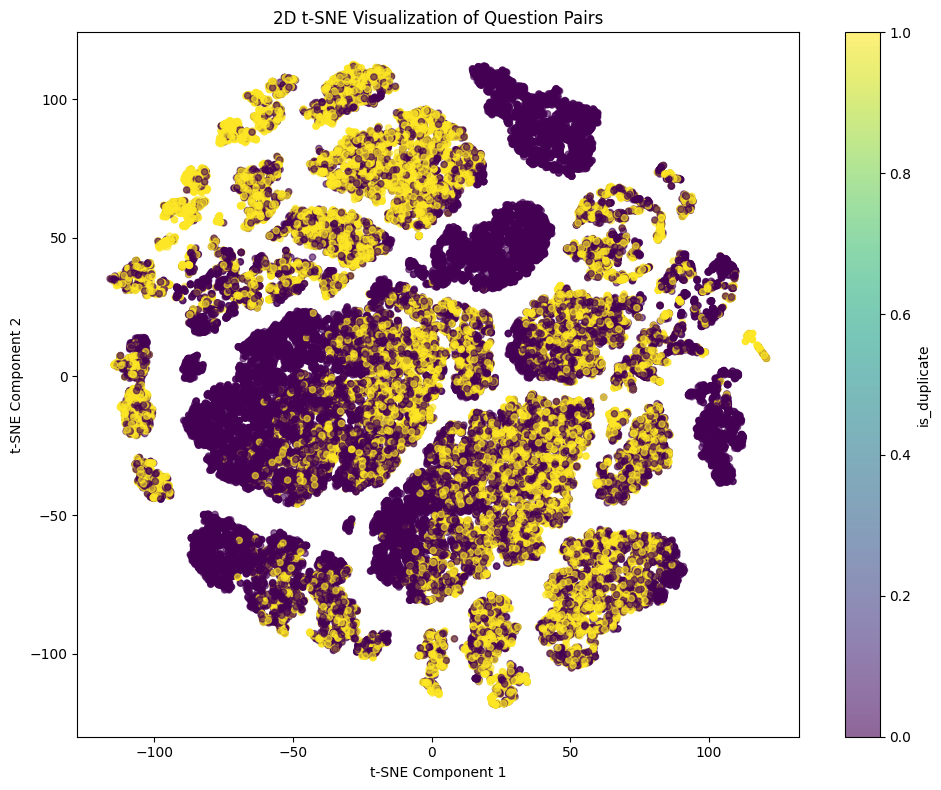

In [29]:
# Visualize 2D t-SNE
plt.figure(figsize=(10, 8))
scatter = plt.scatter(tsne2d[:, 0], tsne2d[:, 1], c=y, cmap='viridis', alpha=0.6, s=20)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('2D t-SNE Visualization of Question Pairs')
plt.colorbar(scatter, label='is_duplicate')
plt.tight_layout()
plt.show()

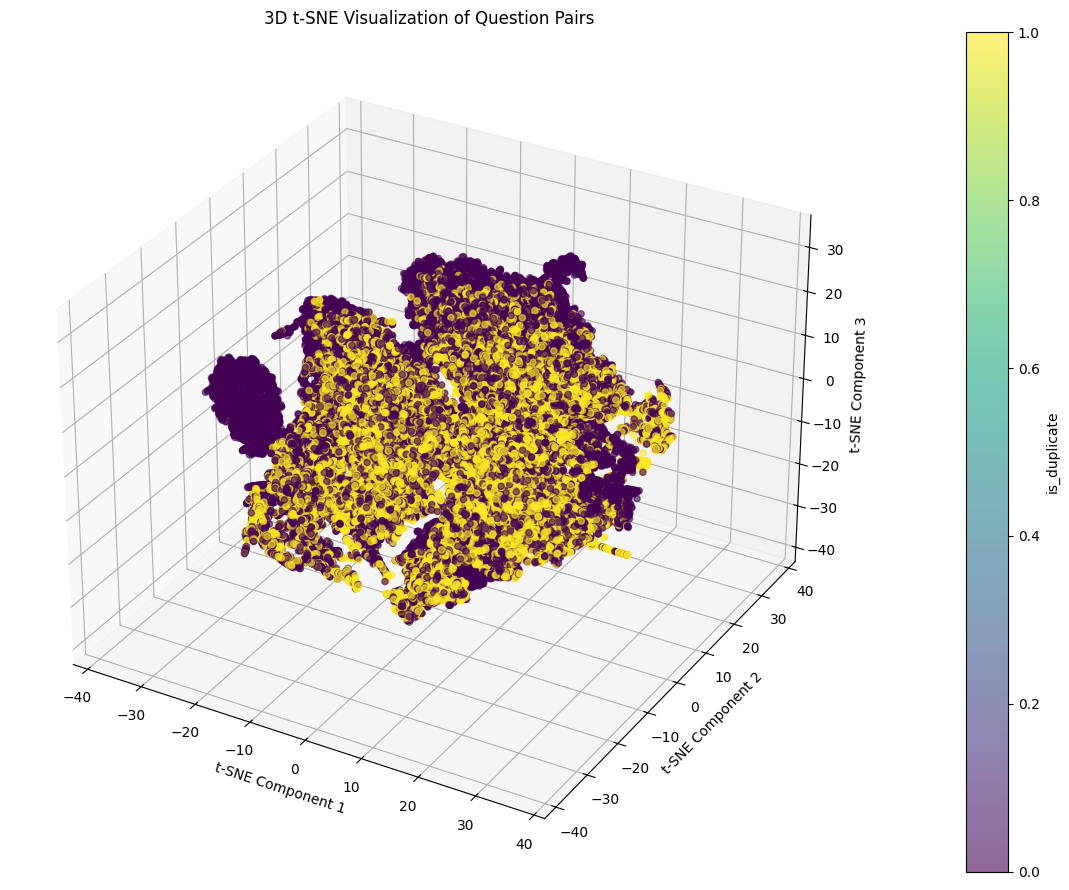

In [30]:
# Visualize 3D t-SNE
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(tsne3d[:, 0], tsne3d[:, 1], tsne3d[:, 2], c=y, cmap='viridis', alpha=0.6, s=20)
ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.set_zlabel('t-SNE Component 3')
ax.set_title('3D t-SNE Visualization of Question Pairs')
plt.colorbar(scatter, label='is_duplicate', pad=0.1)
plt.tight_layout()
plt.show()

In [31]:
ques_df= new_df[["question1","question2","is_duplicate"]]
ques_df.head()

,question1,question2,is_duplicate
8067,how do i play pokémon go in korea,how do i play pokémon go in china,0
368101,what are some of the best side dishes for crab...,what are some good side dishes for buffalo chi...,0
70497,which is more advisable and better material fo...,what is the best server setup for buddypress,0
226567,how do i improve logical programming skills,how can i improve my logical skills for progra...,1
73186,how close we are to see 3rd world war,how close is a world war iii,1


In [32]:
final_df = new_df.drop(columns = ['id','qid1','qid2','question1','question2'])
print(final_df.shape)
final_df.head()

(60000, 23)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,words_common,total_words,word_share,cwc_min,cwc_max,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_qratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
8067,0,33,33,8,8,7,16,0.437500,0.749981,0.749981,...,0.874989,0.0,1.0,0.0,8.0,0.823529,0.88,0.88,0.81,0.90
368101,0,52,50,11,9,6,20,0.300000,0.399992,0.399992,...,0.545450,0.0,1.0,2.0,10.0,0.333333,0.73,0.72,0.73,0.73
70497,0,94,44,16,8,2,24,0.083333,0.000000,0.000000,...,0.124999,0.0,0.0,50.0,12.0,0.111111,0.35,0.43,0.36,0.24
226567,1,43,51,7,9,6,16,0.375000,0.999975,0.999975,...,0.666659,0.0,1.0,8.0,8.0,0.272727,0.72,0.67,0.89,0.96
73186,1,37,28,9,7,4,16,0.250000,0.749981,0.599988,...,0.444440,0.0,1.0,9.0,8.0,0.344828,0.68,0.61,0.71,0.81


In [33]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
questions = list(ques_df['question1']) + list(ques_df['question2'])
cv = CountVectorizer(max_features=3000)
q1_arr ,q2_arr = np.vsplit(cv.fit_transform(questions).toarray(),2)

In [34]:
temp_df1 = pd.DataFrame(q1_arr,index=ques_df.index)
temp_df2 = pd.DataFrame(q2_arr,index=ques_df.index)
temp_df = pd.concat([temp_df1,temp_df2],axis=1)
temp_df.shape

(60000, 6000)

In [35]:
final_df = pd.concat([final_df,temp_df],axis=1)
final_df.shape


(60000, 6023)

In [36]:
final_df.head()

,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,words_common,total_words,word_share,cwc_min,cwc_max,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
8067,0,33,33,8,8,7,16,0.437500,0.749981,0.749981,...,0,0,0,0,0,0,0,0,0,0
368101,0,52,50,11,9,6,20,0.300000,0.399992,0.399992,...,0,0,0,0,0,0,0,0,0,0
70497,0,94,44,16,8,2,24,0.083333,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,0
226567,1,43,51,7,9,6,16,0.375000,0.999975,0.999975,...,0,0,0,0,0,0,0,0,0,0
73186,1,37,28,9,7,4,16,0.250000,0.749981,0.599988,...,0,0,0,0,0,0,0,0,0,0


In [37]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(final_df.iloc[:,1:].values,final_df.iloc[:,0].values,test_size=0.2,random_state=42)

In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier(random_state=42)
rf.fit(x_train,y_train)
y_pred = rf.predict(x_test)
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.8025833333333333


In [39]:
x_train.shape

(48000, 6022)

In [40]:
from xgboost import XGBClassifier  

xgb = XGBClassifier()
xgb.fit(x_train, y_train)
y_pred_xgb = xgb.predict(x_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb)) 

XGBoost Accuracy: 0.8008333333333333


In [41]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred))
print(confusion_matrix(y_test,y_pred_xgb))

[[6486 1026]
 [1343 3145]]
[[6367 1145]
 [1245 3243]]


In [42]:
def query_point_creator(q1,q2):
    
    input_query = []
    #preprocess the questions
    q1 = preprocess_text(q1)
    q2 = preprocess_text(q2)

    #fetch basic features
    input_query.append(len(q1))
    input_query.append(len(q2))

    input_query.append(len(q1.split(" ")))
    input_query.append(len(q2.split(" ")))

    row = {"question1": q1, "question2": q2}

    cw = common_words(row)
    tw = total_words(row)
    input_query.append(cw)
    input_query.append(tw)
    input_query.append(round(cw/tw,2))

    #fetch token features
    token_features = fetch_token_features({"question1": q1, "question2": q2})
    input_query.extend(token_features)

    #fetch length features
    length_features = fetch_length_features({"question1": q1, "question2": q2})
    input_query.extend(length_features)

    #fetch fuzzy features
    fuzzy_features = fetch_fuzzy_features({"question1": q1, "question2": q2})
    input_query.extend(fuzzy_features)


    q1_tfidf = cv.transform([q1]).toarray()
    q2_tfidf = cv.transform([q2]).toarray()

    return np.hstack((np.array(input_query),q1_tfidf[0],q2_tfidf[0])).reshape(1,-1)


In [43]:
q1 = 'Where is the capital of India?'
q2 = 'What is the capital of India?'


In [44]:
x = query_point_creator(q1,q2)
print(x.shape)


(1, 6022)


In [45]:
print(len(cv.get_feature_names_out()))


3000


In [46]:
rf.predict(query_point_creator(q1,q2))

array([1])

In [47]:
import pickle

pickle.dump(rf, open("model.pkl","wb"))
pickle.dump(cv,open('cv.pkl','wb'))